In [10]:
import numpy as np
import matplotlib.pyplot as plt 

In [11]:
#Word embeddings 
word_embeddings= {
    "cat":[0.8,0.6],
    "kitten":[0.75,0.65],
    "dog": [0.7, 0.3],
    "puppy": [0.65, 0.35],
    "car": [-0.5, 0.2],
    "truck": [-0.45, 0.15]
} 

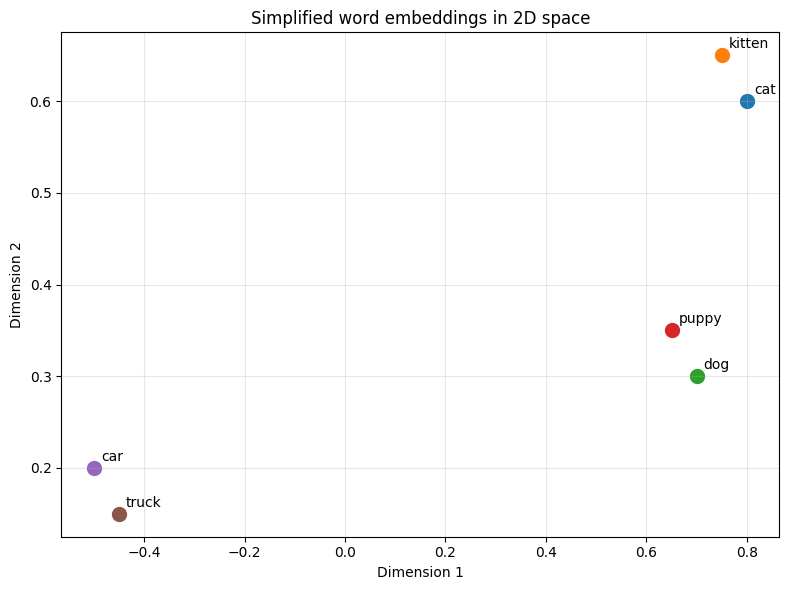

In [12]:
fig,ax = plt.subplots(figsize =(8,6))
for words,coords in word_embeddings.items():
    ax.scatter(coords[0], coords[1], s=100)
    ax.annotate(words, (coords[0], coords[1]), xytext=(5, 5), 
                textcoords='offset points')
ax.set_xlabel('Dimension 1')
ax.set_ylabel("Dimension 2")
ax.set_title("Simplified word embeddings in 2D space")
ax.grid(True,alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
def cosine_similarity(vec1,vec2):
    """Cosine similarity measures the angle between two vectors
    - Result close to 1: Very similar
    - Result close to 0: Not related
    - Result close to -1: Not related """
    dot_product = np.dot(vec1,vec2)
    norm_a=np.linalg.norm(vec1)
    norm_b = np.linalg.norm(vec2)
    return dot_product/(norm_a*norm_b)

### If the result close to 1 means both are very similar

In [14]:
#Example
cat_vector =  [0.8, 0.6, 0.3]
kitten_vector = [0.75, 0.65, 0.35]
car_vector= [-0.5, 0.2, 0.1]
cat_kitten_similarity = cosine_similarity(cat_vector,kitten_vector)
print(cat_kitten_similarity)
if cat_kitten_similarity >= 0.8:
    print("Both cat and kitten are similar") 
else:
    print("Not similar")

0.9966186334192181
Both cat and kitten are similar


### Creating My First Embedding

In [16]:
### Huggingface and OpenAI models
from langchain_huggingface import HuggingFaceEmbeddings 
### Intialize a simple Embedding model (no API Key Needed)
embeddings = HuggingFaceEmbeddings(
    model_name = "sentence-transformers/all-MiniLM-L6-v2"
)
embeddings

HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2', cache_folder=None, model_kwargs={}, encode_kwargs={}, query_encode_kwargs={}, multi_process=False, show_progress=False)

In [19]:
text = "Hello, I am learning about embeddings!"
embedding = embeddings.embed_query(text)
print(f"Text: {text}")
print(f"embedding length:{len(embedding)}")
print(embedding)
print(f"printing last embedding value, 383, value embedding[383] = {embedding[383]}")

Text: Hello, I am learning about embeddings!
embedding length:384
[-0.018163267523050308, -0.09955167025327682, 0.013816090300679207, -0.00812592078000307, 0.01415219809859991, 0.06406485289335251, -0.006253338418900967, -0.0030178832821547985, 0.025287283584475517, -0.020198635756969452, 0.02432974986732006, 0.07435058802366257, 0.05117715522646904, 0.022038394585251808, -0.05830620229244232, 0.0152682363986969, 0.02358437515795231, 0.09455397725105286, -0.06508845090866089, 0.013296672143042088, -0.020497579127550125, -0.056908514350652695, 0.03030334785580635, -0.08365613222122192, 0.026596292853355408, -0.0152314193546772, -0.04361538961529732, 0.05398397892713547, 0.09025714546442032, -0.08893883228302002, 0.03964461013674736, -0.008834989741444588, -0.030343735590577126, 0.07425563782453537, -0.05409916117787361, 0.11107999086380005, 0.0368998758494854, -0.008959813043475151, -0.061402421444654465, -0.0031433666590601206, 0.021958181634545326, 0.04220818355679512, -0.028937829658

### Embedding of sentetnces

In [21]:
sentences = [
    "The cat sat on the mat",
    "The cat sat on the mat",
    "The dog played in the yard",
    "I love programming in Python",
    "Python is my favorite programming language"
]
#Following converts every line of sentence into a embedding vector
embedding_sentences=embeddings.embed_documents(sentences)
print(f"3rd sentence: {sentences[2]}, embedding = {embedding_sentences[2]}")
print(f"5th sentence: {sentences[4]}, embedding = {embedding_sentences[4]}")


3rd sentence: The dog played in the yard, embedding = [0.057315435260534286, -0.04909416288137436, 0.02334265038371086, 0.009190014563500881, 0.05752968415617943, 0.02386520430445671, -0.006997040007263422, 0.026494840160012245, 0.015788868069648743, 0.07033315300941467, 0.010862700641155243, 0.03158722445368767, 0.024720454588532448, 0.03916427865624428, 0.07700895518064499, 0.0754360482096672, -0.030417321249842644, 0.009976173751056194, 0.004732927773147821, -0.09102341532707214, -0.09431751817464828, 0.06867232173681259, 0.05544598773121834, -0.05071733891963959, -0.08527243137359619, -0.04218315705657005, 0.0035109715536236763, 0.06987089663743973, -0.027942152693867683, -0.0646267831325531, 0.0156144043430686, 0.020888885483145714, -0.021623823791742325, 0.002755511552095413, -0.03367350995540619, 0.01977982372045517, 0.029589219018816948, -0.052088040858507156, 0.06737291067838669, 0.08001774549484253, 0.017433101311326027, 0.005021074321120977, 0.03923965245485306, -0.017320882